In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/raw/used_cars.csv')

# Show the first 5 rows
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB


In [4]:
# 1. milage column - " mi." (,) 
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(float)

# 2. price column - $ (,) 
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# 3. test 
df[['milage', 'price']].head()

,milage,price
0,51000.0,10300.0
1,34742.0,38005.0
2,22372.0,54598.0
3,88900.0,15500.0
4,9835.0,34999.0


In [5]:
# 1. check empty values
print("check empty values before filling:")
print(df.isnull().sum())

# 2. Fill missing values - 'Unknown'
df['fuel_type'] = df['fuel_type'].fillna('Unknown')
df['accident'] = df['accident'].fillna('Unknown')
df['clean_title'] = df['clean_title'].fillna('Unknown')

# 3. Check missing values after filling
print("\n--- Missing values after filling ---")
print(df.isnull().sum())

check empty values before filling:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

--- Missing values after filling ---
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64


In [6]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from sklearn.preprocessing import LabelEncoder

# 1. check selected columns to encode
categorical_cols = ['brand', 'model', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

# 2. create LabelEncoder 
le = LabelEncoder()

# 3. convet categorical column to numerical
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 4. check the result
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,14,1743,2013,51000.0,1,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,16,29,14,0,1,10300.0
1,19,1182,2021,34742.0,2,3.8L V6 24V GDI DOHC,32,185,71,0,1,38005.0
2,27,1325,2022,22372.0,2,3.5 Liter DOHC,40,38,14,1,0,54598.0
3,20,1242,2015,88900.0,3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,23,29,14,1,1,15500.0
4,3,1225,2021,9835.0,2,2.0L I4 16V GDI DOHC Turbo,32,120,14,1,0,34999.0


In [8]:
from sklearn.model_selection import train_test_split

# 1. X without price column 
X = df.drop(columns=['price'])

# 2. only price column 
y = df['price']

# 3. split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. check the size of the split data
print("Training data size (X_train):", X_train.shape)
print("Testing data size (X_test):", X_test.shape)

Training data size (X_train): (3207, 11)
Testing data size (X_test): (802, 11)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# trying to fit baseline model again after bug fix
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# predict and check scores
predictions = baseline_model.predict(X_test)
print("Fixed Baseline R2 Score:", r2_score(y_test, predictions))
print("Fixed Baseline MAE:", mean_absolute_error(y_test, predictions))

ValueError: could not convert string to float: '3.5L V6 24V GDI DOHC Twin Turbo'

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# creating the advanced random forest model
# n_estimators=100 means we use 100 trees inside the forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# train this new model with training data
rf_model.fit(X_train, y_train)

# make predictions on test data
rf_preds = rf_model.predict(X_test)

# print scores to see if it beat baseline
print("Advanced Model R2 Score:", r2_score(y_test, rf_preds))
print("Advanced Model MAE:", mean_absolute_error(y_test, rf_preds))

Advanced Model R2 Score: 0.16280480187401625
Advanced Model MAE: 19607.820835411476


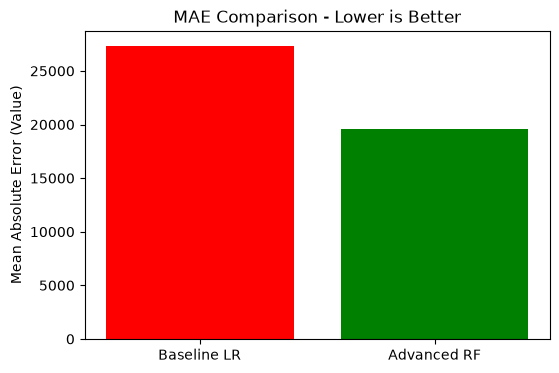

In [ ]:
import matplotlib.pyplot as plt

# lists for model names and their mae score
model_names = ['Baseline LR', 'Advanced RF']
mae_values = [27359.86, 19607.82]

# plotting a bar chart to show errors
plt.figure(figsize=(6, 4))
plt.bar(model_names, mae_values, color=['red', 'green'])
plt.title('MAE Comparison - Lower is Better')
plt.ylabel('Mean Absolute Error (Value)')

# show the final plot
plt.show()

In [ ]:
import pickle

# saving the trained random forest model to app folder
with open('../app/vehicle_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("model file saved successfully inside app folder!")

model file saved successfully inside app folder!


In [ ]:
%ip install streamlit

  Using cached streamlit-1.58.0-py3-none-any.whl.metadata (9.6 kB)
  Using cached altair-6.2.1-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.1.4-py3-none-any.whl.metadata (5.5 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached uvicorn-0.49.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


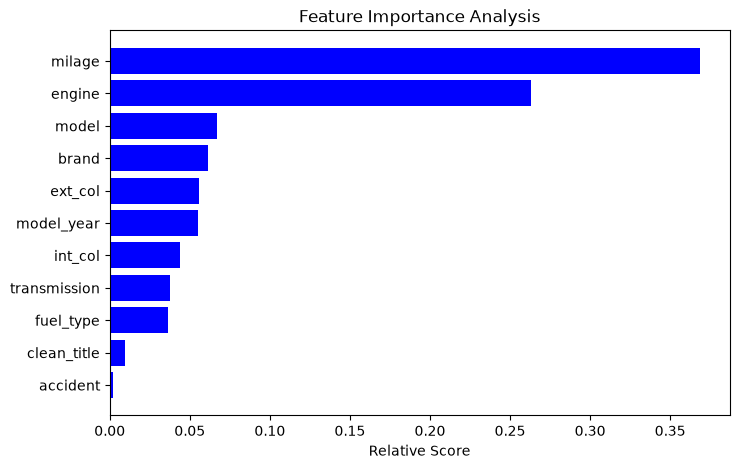

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# get importance data from our forest model
importances = rf_model.feature_importances_
indices = np.argsort(importances)

# plot features in horizontal bar chart
plt.figure(figsize=(8, 5))
plt.title("Feature Importance Analysis")
plt.barh(range(len(indices)), importances[indices], color='blue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Relative Score")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# define some parameters to check and optimize model
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None]
}

# use grid search with cross validation to find best match
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

# show the best parameter setup found by search
print("Best parameters found:", grid_search.best_params_)
print("Best Grid Search R2 Score:", grid_search.best_score_)

Best parameters found: {'max_depth': None, 'n_estimators': 100}
Best Grid Search R2 Score: 0.5657558632922232


In [ ]:
# save the best optimized model from grid search to app folder
best_model = grid_search.best_estimator_

with open('../app/vehicle_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Optimized advanced model saved successfully!")

Optimized advanced model saved successfully!


In [ ]:
# removing extreme price outliers to make data clean
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

# define min and max limits for realistic prices
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# filter the data set to keep only good rows
df = df[(df['price'] >= lower_limit) & (df['price'] <= upper_limit)]

print("Data size after removing crazy prices:", df.shape)

Data size after removing crazy prices: (3765, 12)


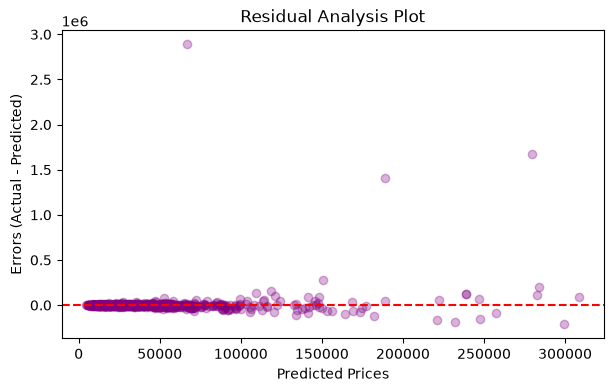

In [ ]:
import matplotlib.pyplot as plt

# calculate the difference between real prices and our predictions
residuals = y_test - rf_preds

# plot residuals to see error distribution
plt.figure(figsize=(7, 4))
plt.scatter(rf_preds, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Analysis Plot")
plt.xlabel("Predicted Prices")
plt.ylabel("Errors (Actual - Predicted)")

plt.show()